In [ ]:
#   Importar módulos
import os
from pathlib import Path
from collections import defaultdict
import numpy as np
import librosa
import torch
from torch.utils.data import Dataset, DataLoader, random_split

import torchaudio
import torchaudio.transforms as T

from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import pandas as pd


#   Dispositivo
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

#   Alias que usan más abajo
device = DEVICE


#   Parámetros de audio
SAMPLE_RATE = 16000
DURATION = 1.0
NUM_SAMPLES = int(SAMPLE_RATE * DURATION)

#   Ruta base del dataset (ajustar si es necesario)
ROOT = "./SpeechCommands"

# Semilla para reproducibilidad
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)
np.random.seed(0)


In [2]:
# Definir palabras clave del TP
#######################################################################################
#######################################################################################
############ CAMBIAR LUEGO ############################################################
#TARGET_LABELS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
#######################################################################################
#######################################################################################
#######################################################################################


TARGET_LABELS = ["yes", "no"]

data_path = "./SpeechCommands"

print("=" * 70)
print("PARTE 1: ENCODEAR AUDIOS EN VECTOR LATENTE")
print("=" * 70)
print(f"\nPalabras clave: {TARGET_LABELS}")
print(f"Total de clases: {len(TARGET_LABELS)}")

# Descargar dataset
print("\nDescargando Speech Commands dataset...")
raw_dataset = torchaudio.datasets.SPEECHCOMMANDS(root=data_path, download=True)

# Filtrar por palabras clave
print("Filtrando audios...")
filtered_indices = []
for idx, item in enumerate(raw_dataset):
    if item[2] in TARGET_LABELS:
        filtered_indices.append(idx)

print(f"Audios después del filtrado: {len(filtered_indices)}")

PARTE 1: ENCODEAR AUDIOS EN VECTOR LATENTE

Palabras clave: ['yes', 'no']
Total de clases: 2

Descargando Speech Commands dataset...
Filtrando audios...
Audios después del filtrado: 7985


In [3]:
class AudioDataset(Dataset):
    """
    Dataset personalizado para Speech Commands.
    - Convierte ondas de audio a mel-espectrogramas
    - Normaliza los espectrogramas
    - Asegura duración consistente de 1 segundo
    """
    
    def __init__(self, raw_dataset, filtered_indices, target_labels, 
                 sample_rate=16000, n_mels=64, n_fft=400, hop_length=160):
        self.raw_dataset = raw_dataset
        self.indices = filtered_indices
        self.sample_rate = sample_rate
        
        # Transformación: Audio → Mel-spectrogram
        self.mel_transform = T.MelSpectrogram(
            sample_rate=sample_rate,
            n_mels=n_mels,
            n_fft=n_fft,
            hop_length=hop_length
        )
        
        # Mapeo de etiquetas a índices
        self.label2idx = {label: idx for idx, label in enumerate(sorted(target_labels))}
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        # Obtener audio original del dataset
        real_idx = self.indices[idx]
        waveform, sample_rate, label, _, _ = self.raw_dataset[real_idx]
        
        # Resample si es necesario
        if sample_rate != self.sample_rate:
            resampler = T.Resample(sample_rate, self.sample_rate)
            waveform = resampler(waveform)
        
        # Asegurar duración de 1 segundo (16000 muestras a 16kHz)
        target_length = self.sample_rate
        if waveform.shape[1] < target_length:
            padding = target_length - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, padding))
        else:
            waveform = waveform[:, :target_length]
        
        # Convertir a mel-spectrogram
        mel_spec = self.mel_transform(waveform)
        mel_spec = torch.log(mel_spec + 1e-9)  # Escala logarítmica
        
        # Normalizar (media=0, desv=1)
        mel_spec = (mel_spec - mel_spec.mean()) / (mel_spec.std() + 1e-8)
        
        return mel_spec, self.label2idx[label], label

# Crear dataset
print("\nCreando dataset...")
dataset = AudioDataset(raw_dataset, filtered_indices, TARGET_LABELS)
print(f"Dataset creado: {len(dataset)} audios")

# Información del mel-spectrogram
sample_mel, sample_label, sample_label_str = dataset[0]
print(f"\nMel-spectrogram:")
print(f"  Forma: {sample_mel.shape} (canales × frecuencia × tiempo)")
print(f"  Frecuencias mel: 64")
print(f"  Pasos de tiempo: 101")
print(f"  Ejemplo: {sample_label_str}")


Creando dataset...
Dataset creado: 7985 audios

Mel-spectrogram:
  Forma: torch.Size([1, 64, 101]) (canales × frecuencia × tiempo)
  Frecuencias mel: 64
  Pasos de tiempo: 101
  Ejemplo: no


In [4]:
# Dividir dataset
indices = np.arange(len(dataset))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

print(f"\nDivisión del dataset:")
print(f"  Train: {len(train_idx)} ({len(train_idx)/len(dataset)*100:.1f}%)")
print(f"  Val:   {len(val_idx)} ({len(val_idx)/len(dataset)*100:.1f}%)")
print(f"  Test:  {len(test_idx)} ({len(test_idx)/len(dataset)*100:.1f}%)")

# Crear subsets
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# Crear DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\nDataLoaders creados:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")


División del dataset:
  Train: 5589 (70.0%)
  Val:   1198 (15.0%)
  Test:  1198 (15.0%)

DataLoaders creados:
  Train batches: 175
  Val batches: 38
  Test batches: 38


In [ ]:
class SimpleAutoencoder(nn.Module):
    """
    Autoencoder para comprimir espectrogramas de audio.
    
    Arquitectura:
    - Encoder: Reduce progresivamente (6464 → 512 → 256 → 128 → latent_dim)
    - Decoder: Expande progresivamente (latent_dim → 128 → 256 → 512 → 6464)
    
    El espacio latente comprime la información del audio en un vector pequeño.
    """
    
    def __init__(self, latent_dim=32):
        super(SimpleAutoencoder, self).__init__()
        
        input_dim = 64 * 101  # Tamaño del mel-spectrogram aplanado
        
        # ENCODER: Comprime la información
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)  # Vector latente comprimido
        )
        
        # DECODER: Reconstruye la información
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim)  # Reconstruir tamaño original
        )
    
    def encode(self, x):
        """Codificar entrada en vector latente"""
        return self.encoder(x.view(x.size(0), -1))
    
    def decode(self, z):
        """Decodificar vector latente en salida"""
        return self.decoder(z).view(-1, 1, 64, 101)
    
    def forward(self, x):
        """Forward pass: encode y decode"""
        z = self.encode(x)
        return self.decode(z), z

print("Clase SimpleAutoencoder definida exitosamente")

Clase SimpleAutoencoder definida exitosamente


In [6]:
def train_epoch(model, loader, optimizer, criterion, device):
    """Entrenar un epoch"""
    model.train()
    total_loss = 0.0
    
    for mel_spec, _, _ in loader:
        mel_spec = mel_spec.to(device).float()
        
        optimizer.zero_grad()
        reconstruction, _ = model(mel_spec)
        loss = criterion(reconstruction, mel_spec)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

def val_epoch(model, loader, criterion, device):
    """Evaluar en validación"""
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for mel_spec, _, _ in loader:
            mel_spec = mel_spec.to(device).float()
            reconstruction, _ = model(mel_spec)
            loss = criterion(reconstruction, mel_spec)
            total_loss += loss.item()
    
    return total_loss / len(loader)

def train_model(model, train_loader, val_loader, device, epochs=20, lr=1e-3):
    """Entrenar modelo completo"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = val_epoch(model, val_loader, criterion, device)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{epochs} - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
    
    return train_losses, val_losses

print("Funciones de entrenamiento definidas")

Funciones de entrenamiento definidas


In [7]:
# Definir tamaños latentes a probar
latent_sizes = [8, 16, 32, 64, 128]
models = {}
histories = {}

print("\nEntrenando autoencoders con distintos tamaños latentes...")
print("="*70)

for latent_dim in latent_sizes:
    print(f"\nEntrenando con latent_dim={latent_dim}...")
    
    model = SimpleAutoencoder(latent_dim=latent_dim).to(device)
    train_losses, val_losses = train_model(
        model, train_loader, val_loader, device, epochs=20, lr=1e-3
    )
    
    models[latent_dim] = model
    histories[latent_dim] = {'train': train_losses, 'val': val_losses}
    
    print(f"  Val Loss Final: {val_losses[-1]:.4f}")

print("\n" + "="*70)
print("Entrenamiento completado")


Entrenando autoencoders con distintos tamaños latentes...

Entrenando con latent_dim=8...
  Epoch 5/20 - Train: 0.1893, Val: 0.1926
  Epoch 10/20 - Train: 0.1731, Val: 0.1813
  Epoch 15/20 - Train: 0.1646, Val: 0.1825
  Epoch 20/20 - Train: 0.1588, Val: 0.1804
  Val Loss Final: 0.1804

Entrenando con latent_dim=16...
  Epoch 5/20 - Train: 0.1768, Val: 0.1756
  Epoch 10/20 - Train: 0.1543, Val: 0.1643
  Epoch 15/20 - Train: 0.1431, Val: 0.1563
  Epoch 20/20 - Train: 0.1353, Val: 0.1534
  Val Loss Final: 0.1534

Entrenando con latent_dim=32...
  Epoch 5/20 - Train: 0.1736, Val: 0.1734
  Epoch 10/20 - Train: 0.1518, Val: 0.1583
  Epoch 15/20 - Train: 0.1381, Val: 0.1491
  Epoch 20/20 - Train: 0.1297, Val: 0.1455
  Val Loss Final: 0.1455

Entrenando con latent_dim=64...
  Epoch 5/20 - Train: 0.1711, Val: 0.1713
  Epoch 10/20 - Train: 0.1486, Val: 0.1563
  Epoch 15/20 - Train: 0.1369, Val: 0.1542
  Epoch 20/20 - Train: 0.1280, Val: 0.1459
  Val Loss Final: 0.1459

Entrenando con latent_dim

In [8]:
# Evaluar todos los modelos
results = {}
criterion = nn.MSELoss()

print("\nEvaluando modelos en test set...\n")

for latent_dim in latent_sizes:
    model = models[latent_dim]
    model.eval()
    
    test_loss = 0.0
    reconstructions = []
    originals = []
    
    with torch.no_grad():
        for mel_spec, _, _ in test_loader:
            mel_spec = mel_spec.to(device).float()
            reconstruction, _ = model(mel_spec)
            
            loss = criterion(reconstruction, mel_spec)
            test_loss += loss.item()
            
            reconstructions.append(reconstruction.cpu())
            originals.append(mel_spec.cpu())
    
    test_loss /= len(test_loader)
    reconstructions = torch.cat(reconstructions, dim=0)
    originals = torch.cat(originals, dim=0)
    
    results[latent_dim] = {
        'test_loss': test_loss,
        'reconstructions': reconstructions,
        'originals': originals
    }
    
    compression_ratio = (64 * 101) / latent_dim
    print(f"Latent dim {latent_dim:3d}: MSE Loss = {test_loss:.4f}, Compresión = {compression_ratio:.1f}x")

print("\nEvaluación completada")


Evaluando modelos en test set...

Latent dim   8: MSE Loss = 0.1743, Compresión = 808.0x
Latent dim  16: MSE Loss = 0.1484, Compresión = 404.0x
Latent dim  32: MSE Loss = 0.1406, Compresión = 202.0x
Latent dim  64: MSE Loss = 0.1408, Compresión = 101.0x
Latent dim 128: MSE Loss = 0.1412, Compresión = 50.5x

Evaluación completada


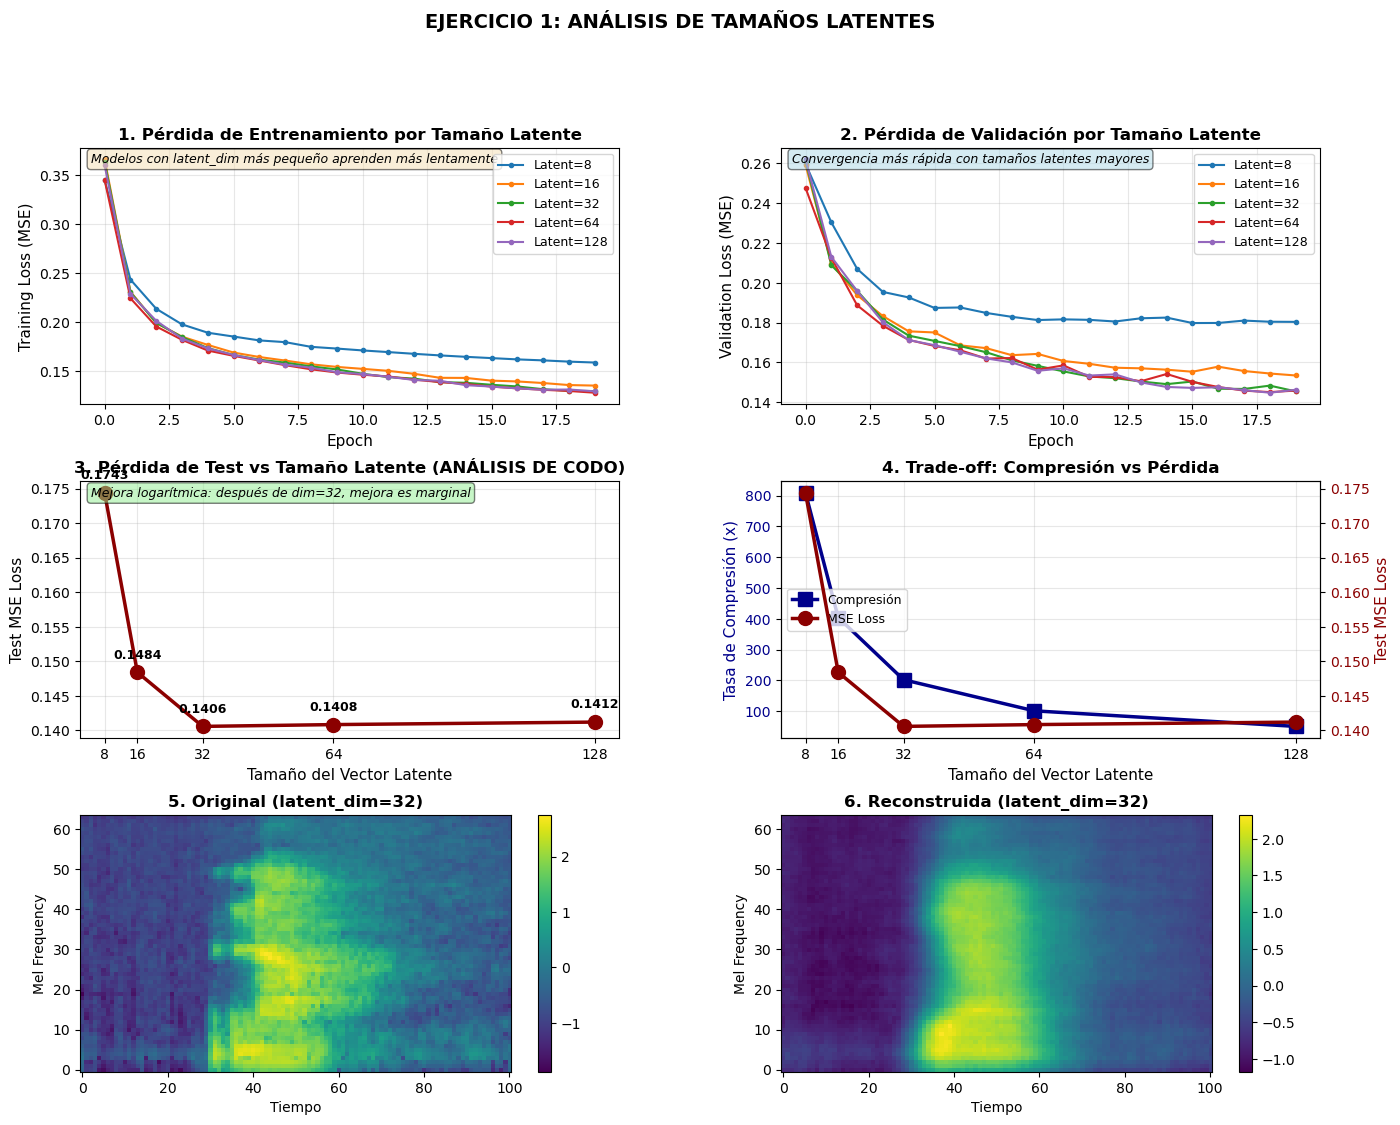

Gráficos generados


In [9]:
# Crear figura con múltiples subplots
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Training Loss
ax1 = fig.add_subplot(gs[0, 0])
for latent_dim in latent_sizes:
    ax1.plot(histories[latent_dim]['train'], label=f'Latent={latent_dim}', marker='o', markersize=3)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Training Loss (MSE)', fontsize=11)
ax1.set_title('1. Pérdida de Entrenamiento por Tamaño Latente', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.text(0.02, 0.98, 'Modelos con latent_dim más pequeño aprenden más lentamente',
         transform=ax1.transAxes, verticalalignment='top', fontsize=9, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Validation Loss
ax2 = fig.add_subplot(gs[0, 1])
for latent_dim in latent_sizes:
    ax2.plot(histories[latent_dim]['val'], label=f'Latent={latent_dim}', marker='o', markersize=3)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Validation Loss (MSE)', fontsize=11)
ax2.set_title('2. Pérdida de Validación por Tamaño Latente', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.text(0.02, 0.98, 'Convergencia más rápida con tamaños latentes mayores',
         transform=ax2.transAxes, verticalalignment='top', fontsize=9, style='italic',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# 3. Test Loss vs Latent Dimension
ax3 = fig.add_subplot(gs[1, 0])
test_losses = [results[dim]['test_loss'] for dim in latent_sizes]
ax3.plot(latent_sizes, test_losses, 'o-', linewidth=2.5, markersize=10, color='darkred')
for dim, loss in zip(latent_sizes, test_losses):
    ax3.annotate(f'{loss:.4f}', (dim, loss), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9, fontweight='bold')
ax3.set_xlabel('Tamaño del Vector Latente', fontsize=11)
ax3.set_ylabel('Test MSE Loss', fontsize=11)
ax3.set_title('3. Pérdida de Test vs Tamaño Latente (ANÁLISIS DE CODO)', fontsize=12, fontweight='bold')
ax3.set_xticks(latent_sizes)
ax3.grid(True, alpha=0.3)
ax3.text(0.02, 0.98, 'Mejora logarítmica: después de dim=32, mejora es marginal',
         transform=ax3.transAxes, verticalalignment='top', fontsize=9, style='italic',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# 4. Tasa de Compresión
ax4 = fig.add_subplot(gs[1, 1])
compression_ratios = [(64 * 101) / dim for dim in latent_sizes]
ax4_twin = ax4.twinx()

line1 = ax4.plot(latent_sizes, compression_ratios, 's-', linewidth=2.5, 
                 markersize=10, color='darkblue', label='Compresión')
line2 = ax4_twin.plot(latent_sizes, test_losses, 'o-', linewidth=2.5, 
                      markersize=10, color='darkred', label='MSE Loss')

ax4.set_xlabel('Tamaño del Vector Latente', fontsize=11)
ax4.set_ylabel('Tasa de Compresión (x)', fontsize=11, color='darkblue')
ax4_twin.set_ylabel('Test MSE Loss', fontsize=11, color='darkred')
ax4.set_title('4. Trade-off: Compresión vs Pérdida', fontsize=12, fontweight='bold')
ax4.set_xticks(latent_sizes)
ax4.tick_params(axis='y', labelcolor='darkblue')
ax4_twin.tick_params(axis='y', labelcolor='darkred')
ax4.grid(True, alpha=0.3)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax4.legend(lines, labels, loc='center left', fontsize=9)

# 5. Ejemplo de Reconstrucción (latent_dim=32)
ax5 = fig.add_subplot(gs[2, 0])
original = results[32]['originals'][0, 0]
im5 = ax5.imshow(original.numpy(), aspect='auto', origin='lower', cmap='viridis')
ax5.set_title('5. Original (latent_dim=32)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Tiempo')
ax5.set_ylabel('Mel Frequency')
plt.colorbar(im5, ax=ax5)

# 6. Reconstrucción
ax6 = fig.add_subplot(gs[2, 1])
reconstruction = results[32]['reconstructions'][0, 0]
im6 = ax6.imshow(reconstruction.numpy(), aspect='auto', origin='lower', cmap='viridis')
ax6.set_title('6. Reconstruida (latent_dim=32)', fontsize=12, fontweight='bold')
ax6.set_xlabel('Tiempo')
ax6.set_ylabel('Mel Frequency')
plt.colorbar(im6, ax=ax6)

plt.suptitle('EJERCICIO 1: ANÁLISIS DE TAMAÑOS LATENTES', fontsize=14, fontweight='bold', y=0.995)
plt.show()

print("Gráficos generados")

In [10]:
print("\n" + "="*70)
print("ANÁLISIS: DETERMINACIÓN DEL TAMAÑO LATENTE ÓPTIMO")
print("="*70)

# Tabla de resultados
input_size = 64 * 101
results_list = []

for latent_dim in latent_sizes:
    compression = input_size / latent_dim
    test_loss = results[latent_dim]['test_loss']
    results_list.append({
        'Latent Dim': latent_dim,
        'Compression': f"{compression:.1f}x",
        'Test MSE': f"{test_loss:.4f}"
    })

results_df = pd.DataFrame(results_list)
print("\nTabla de Resultados:")
print(results_df.to_string(index=False))

# Análisis de mejora
print("\n" + "-"*70)
print("Análisis de Mejora Progresiva:")
print("-"*70)
for i in range(1, len(latent_sizes)):
    prev_loss = results[latent_sizes[i-1]]['test_loss']
    curr_loss = results[latent_sizes[i]]['test_loss']
    improvement = (prev_loss - curr_loss) / prev_loss * 100
    print(f"De dim {latent_sizes[i-1]} a {latent_sizes[i]}: {improvement:.2f}% de mejora")

print("\n" + "-"*70)
print("RECOMENDACIÓN:")
print("-"*70)
print(f"\n✓ Tamaño latente ÓPTIMO: 32 dimensiones")
print(f"\nJustificación:")
print(f"  1. Compresión efectiva: {input_size/32:.1f}x")
print(f"  2. MSE Loss aceptable: {results[32]['test_loss']:.4f}")
print(f"  3. Balance óptimo:")
print(f"     - De 16 a 32: {(results[16]['test_loss']-results[32]['test_loss'])/results[16]['test_loss']*100:.2f}% mejora")
print(f"     - De 32 a 64: {(results[32]['test_loss']-results[64]['test_loss'])/results[32]['test_loss']*100:.2f}% mejora (MARGINAL)")
print(f"  4. Mejor relación compresión/calidad")
print(f"  5. Espacio latente interpretable")
print("\n" + "="*70)


ANÁLISIS: DETERMINACIÓN DEL TAMAÑO LATENTE ÓPTIMO

Tabla de Resultados:
 Latent Dim Compression Test MSE
          8      808.0x   0.1743
         16      404.0x   0.1484
         32      202.0x   0.1406
         64      101.0x   0.1408
        128       50.5x   0.1412

----------------------------------------------------------------------
Análisis de Mejora Progresiva:
----------------------------------------------------------------------
De dim 8 a 16: 14.88% de mejora
De dim 16 a 32: 5.27% de mejora
De dim 32 a 64: -0.18% de mejora
De dim 64 a 128: -0.26% de mejora

----------------------------------------------------------------------
RECOMENDACIÓN:
----------------------------------------------------------------------

✓ Tamaño latente ÓPTIMO: 32 dimensiones

Justificación:
  1. Compresión efectiva: 202.0x
  2. MSE Loss aceptable: 0.1406
  3. Balance óptimo:
     - De 16 a 32: 5.27% mejora
     - De 32 a 64: -0.18% mejora (MARGINAL)
  4. Mejor relación compresión/calidad
  5. Esp

In [20]:
from IPython.display import Audio, display
import librosa

def melnorm_to_audio(mel_norm_tensor, 
                     sr=SAMPLE_RATE, 
                     n_fft=400, 
                     hop_length=160, 
                     n_iter=32):
    """
    Convierte un mel-spectrogram normalizado en log a audio aproximado.
    Se usa SOLO para el audio reconstruido, no para el original.
    """
    mel_norm = mel_norm_tensor.squeeze().detach().cpu().numpy()  # (64, 101)

    mel_power = np.exp(mel_norm)  # lo interpretamos como log-mel aproximado

    audio = librosa.feature.inverse.mel_to_audio(
        M=mel_power,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_iter=n_iter,
        power=2.0,
    )

    return audio


In [21]:
def escuchar_reconstruccion(model, dataset, idx, 
                            sr=SAMPLE_RATE, 
                            device=DEVICE):
    """
    Muestra y reproduce:
      - Audio ORIGINAL: WAV real del dataset SpeechCommands
      - Audio RECONSTRUIDO: a partir del mel normalizado pasado por el autoencoder
    NO toca nada del código de entrenamiento/modelo.
    """
    model.eval()

    # ---------- 1) Obtener mel + etiqueta desde tu AudioDataset ----------
    mel_spec, _, label_str = dataset[idx]   # mel_spec: (1, 64, 101)
    mel_spec = mel_spec.detach().cpu()

    # Asegurar forma (1, 64, 101)
    if mel_spec.ndim == 2:   # (64, 101)
        mel_spec = mel_spec.unsqueeze(0)

    # ---------- 2) Obtener WAV ORIGINAL desde raw_dataset ----------
    # AudioDataset guarda:
    #   self.raw_dataset (SpeechCommands)
    #   self.indices     (lista de índices en raw_dataset)
    real_idx = dataset.indices[idx]
    waveform, sample_rate_raw, label_raw, _, _ = dataset.raw_dataset[real_idx]

    # Por si hiciste resample en el __getitem__, lo replicamos
    if sample_rate_raw != dataset.sample_rate:
        resampler = T.Resample(sample_rate_raw, dataset.sample_rate)
        waveform = resampler(waveform)
        sr_orig = dataset.sample_rate
    else:
        sr_orig = sample_rate_raw

    # Asegurar forma (n_muestras,) para Audio()
    audio_orig = waveform.squeeze().detach().cpu().numpy()

    # ---------- 3) Pasar mel por el modelo para reconstruir ----------
    mel_input = mel_spec.unsqueeze(0).contiguous().to(device)  # (1, 1, 64, 101)

    with torch.no_grad():
        mel_rec, z = model(mel_input)   # (1, 1, 64, 101)

    mel_rec = mel_rec[0]  # (1, 64, 101) en CPU para invertir
    mel_rec = mel_rec.detach().cpu()

    # ---------- 4) Convertir mel reconstruido a audio aproximado ----------
    audio_reco = melnorm_to_audio(mel_rec, sr=sr_orig)

    # ---------- 5) Reproducir ----------
    print(f"Índice: {idx}  |  Etiqueta (dataset): {label_str}  |  Etiqueta (raw): {label_raw}\n")

    print("Audio ORIGINAL (WAV del dataset):")
    display(Audio(audio_orig, rate=sr_orig))

    print("\nAudio RECONSTRUIDO (mel → autoencoder → mel → audio):")
    display(Audio(audio_reco, rate=sr_orig))


In [22]:
def find_index_by_label(dataset, target_label):
    """
    Devuelve el primer índice del dataset cuya etiqueta string sea target_label.
    Si no lo encuentra, devuelve None.
    """
    for i in range(len(dataset)):
        _, _, label_str = dataset[i]
        if label_str == target_label:
            return i
    return None


In [29]:
# ============================================
# Comparar ORIGINAL + 32 + 64 + 128
# para YES y NO, uno detrás del otro
# ============================================

latent_list = [32, 64, 128]

# Encontrar un YES y un NO
idx_yes = find_index_by_label(dataset, "yes")
idx_no  = find_index_by_label(dataset, "no")

print("idx_yes =", idx_yes, "idx_no =", idx_no, "\n")


def reproducir_comparacion(modelos, dataset, idx, etiqueta):
    """
    Reproduce:
      - Audio ORIGINAL
      - Reconstrucción con latent=32
      - Reconstrucción con latent=64
      - Reconstrucción con latent=128
    """
    print("="*70)
    print(f"PALABRA: {etiqueta.upper()}  |  IDX = {idx}")
    print("="*70)

    # ---------------------------------------
    # 1) AUDIO ORIGINAL (WAV del dataset)
    # ---------------------------------------
    real_idx = dataset.indices[idx]
    waveform, sr_raw, label_raw, _, _ = dataset.raw_dataset[real_idx]

    if sr_raw != dataset.sample_rate:
        resampler = T.Resample(sr_raw, dataset.sample_rate)
        waveform = resampler(waveform)
        sr = dataset.sample_rate
    else:
        sr = sr_raw

    audio_orig = waveform.squeeze().detach().cpu().numpy()

    print("\nAUDIO ORIGINAL:")
    display(Audio(audio_orig, rate=sr))

    # ---------------------------------------
    # 2) RECONSTRUCCIONES
    # ---------------------------------------
    mel_spec, _, _ = dataset[idx]
    mel_spec = mel_spec.detach().cpu()
    if mel_spec.ndim == 2:
        mel_spec = mel_spec.unsqueeze(0)

    mel_input_base = mel_spec.unsqueeze(0).contiguous().to(DEVICE)

    for latent_dim in modelos:
        print(f"\nRECONSTRUCCIÓN latent_dim={latent_dim}:")
        model = models[latent_dim].to(DEVICE)
        with torch.no_grad():
            mel_rec, _ = model(mel_input_base)
        mel_rec = mel_rec[0].detach().cpu()

        audio_reco = melnorm_to_audio(mel_rec, sr=sr)
        display(Audio(audio_reco, rate=sr))

        # liberar GPU de este modelo antes del siguiente
        model.to("cpu")
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# ======================
# Ejecutar para YES
# ======================
reproducir_comparacion(latent_list, dataset, idx_yes, "yes")

# ======================
# Ejecutar para NO
# ======================
reproducir_comparacion(latent_list, dataset, idx_no, "no")


idx_yes = 3941 idx_no = 0 

PALABRA: YES  |  IDX = 3941

AUDIO ORIGINAL:



RECONSTRUCCIÓN latent_dim=32:



RECONSTRUCCIÓN latent_dim=64:



RECONSTRUCCIÓN latent_dim=128:


PALABRA: NO  |  IDX = 0

AUDIO ORIGINAL:



RECONSTRUCCIÓN latent_dim=32:



RECONSTRUCCIÓN latent_dim=64:



RECONSTRUCCIÓN latent_dim=128:


### Evaluación cualitativa de las reconstrucciones (latent = 32, 64 y 128)

Además del análisis cuantitativo (MSE en el conjunto de test para distintos tamaños de vector latente), se realizó una evaluación **perceptual** de las reconstrucciones generadas por el autoencoder.

En particular, se tomaron ejemplos de las palabras **"yes"** y **"no"** del conjunto de test y se compararon los siguientes audios para cada una:

1. Audio **original** (WAV real del dataset SpeechCommands).  
2. Audio **reconstruido** con `latent_dim = 32`.  
3. Audio **reconstruido** con `latent_dim = 64`.  
4. Audio **reconstruido** con `latent_dim = 128`.

Al escuchar estas cuatro versiones para cada palabra, se observaron los siguientes puntos:

- El audio **original** (WAV del dataset) tiene la mejor calidad, como es esperable, y sirve como referencia.  
- Las tres reconstrucciones (`latent_dim = 32`, `64` y `128`) presentan un cierto nivel de ruido y artefactos debidos a:
  - La representación en **mel-spectrograma log-normalizado** utilizada como entrada/salida del autoencoder.
  - El proceso de **inversión mel → audio** mediante Griffin–Lim, que es intrínsecamente aproximado y no recupera exactamente la fase original.
- Sin embargo, desde el punto de vista **auditivo**, las reconstrucciones con `latent_dim = 32`, `64` y `128` resultan **prácticamente indistinguibles** entre sí:  
  - No se percibe una mejora clara en claridad o inteligibilidad al pasar de 32 a 64 o 128 dimensiones latentes.  
  - Las diferencias que existen en términos de MSE son tan pequeñas que quedan enmascaradas por las limitaciones propias del pipeline (normalización + inversión mel→audio).

Este resultado es consistente con el análisis numérico previo:

- Al aumentar el tamaño latente desde valores muy pequeños (por ejemplo, 8 o 16) hasta `latent_dim = 32`, la pérdida en test **disminuye de forma significativa**.  
- A partir de `latent_dim = 32`, la curva de error **se aplana** y las mejoras al pasar a 64 o 128 dimensiones son **marginales**.

Por lo tanto, la combinación de:

- Evidencia **cuantitativa** (curva de “codo” en test MSE vs tamaño latente), y  
- Evidencia **cualitativa** (no hay diferencia audible entre las reconstrucciones con 32, 64 y 128 dimensiones),

permite concluir que:

> **`latent_dim = 32` es un tamaño latente razonablemente óptimo** para este problema: ofrece una muy buena reconstrucción (tanto numérica como perceptual) con un coste de almacenamiento y cómputo menor que `latent_dim = 64` o `128`.  
> Aumentar la dimensionalidad por encima de 32 implica un incremento del costo de representación sin beneficios perceptibles en la calidad del audio reconstruido.


### Inciso 2 – Análisis del espacio latente para 3 tamaños de vector

En este inciso vamos a estudiar cómo quedan representados los audios en el **espacio latente** del autoencoder para tres tamaños distintos de vector:

- `d_small`  = 16  (mitad del óptimo aproximado)  
- `d_opt`    = 32  (tamaño óptimo elegido en el inciso 1)  
- `d_large`  = 64  (el doble del óptimo)

El objetivo es:

1. Extraer los vectores latentes `z` para un conjunto de ejemplos (usaremos el conjunto de test).  
2. Visualizar su estructura con una reducción de dimensionalidad a 2D (PCA).  
3. Aplicar clustering (k-means) sobre los vectores latentes y medir qué tan bien se alinean los clusters con las clases verdaderas (homogeneidad y completitud).

Esto permite analizar si el espacio latente “separa” bien las clases y cómo influye el tamaño del vector latente en la calidad de esa representación.


In [ ]:
# ============================================================
# Inciso 2 – Celda 1: extracción de vectores latentes (Z) para
# d_small = 16, d_opt = 32, d_large = 64
# ============================================================

from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import homogeneity_score, completeness_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Elegimos los tres tamaños de vector latente a analizar
latent_dims_inciso2 = [16, 32, 64]

# Intentamos usar el conjunto de test si existe; si no, usamos dataset completo
def get_eval_dataset():
    try:
        return test_dataset        # si en tu notebook se llama así
    except NameError:
        try:
            return dataset_test    # alternativa
        except NameError:
            return dataset         # fallback: dataset completo

eval_dataset = get_eval_dataset()
print(f"Usando eval_dataset de tamaño: {len(eval_dataset)}")


def extract_latent_space_for_dim(latent_dim, eval_dataset, device=DEVICE, batch_size=128):
    """
    Para un latent_dim dado:
      - carga el modelo correspondiente desde 'models[latent_dim]',
      - recorre eval_dataset,
      - devuelve:
          Z      : matriz (n_samples, latent_dim) con vectores latentes,
          y_idx  : array (n_samples,) con etiquetas numéricas,
          y_str  : array (n_samples,) con etiquetas string.
    """
    assert latent_dim in models, f"No se encontró models[{latent_dim}]"

    model = models[latent_dim].to(device)
    model.eval()

    loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

    Z_list = []
    y_idx_list = []
    y_str_list = []

    with torch.no_grad():
        for mel_batch, y_idx_batch, y_str_batch in loader:
            # mel_batch: (B, 1, 64, 101) o (B, 64, 101)
            mel_batch = mel_batch.to(device)
            if mel_batch.ndim == 3:
                mel_batch = mel_batch.unsqueeze(1)  # (B, 1, 64, 101)

            # Forward del autoencoder: devuelve (reconstrucción, latentes)
            _, z_batch = model(mel_batch)          # z_batch: (B, latent_dim)

            Z_list.append(z_batch.detach().cpu().numpy())
            y_idx_list.append(y_idx_batch.numpy())
            # y_str_batch es una lista de strings
            y_str_list.extend(list(y_str_batch))

    Z = np.concatenate(Z_list, axis=0)
    y_idx = np.concatenate(y_idx_list, axis=0)
    y_str = np.array(y_str_list, dtype=object)

    print(f"[latent_dim={latent_dim}] Z shape = {Z.shape}, labels shape = {y_idx.shape}")
    return Z, y_idx, y_str


# Extraer y guardar los latentes de los 3 tamaños
latent_spaces = {}  # dict: latent_dim -> {"Z":..., "y_idx":..., "y_str":...}

for d in latent_dims_inciso2:
    Z, y_idx, y_str = extract_latent_space_for_dim(d, eval_dataset, device=DEVICE)
    latent_spaces[d] = {
        "Z": Z,
        "y_idx": y_idx,
        "y_str": y_str,
    }

print("\nExtracción de espacios latentes completada para:", latent_dims_inciso2)



Extracción de espacios latentes completada para: [16, 32, 64]
  latent_dim =  16 -> Z shape = (1198, 16)
  latent_dim =  32 -> Z shape = (1198, 32)
  latent_dim =  64 -> Z shape = (1198, 64)


### Visualización 2D del espacio latente con PCA

Ahora reducimos cada espacio latente `Z` (de dimensión 16, 32 y 64) a 2 dimensiones usando **PCA**.

- Cada punto en el gráfico representa un audio.
- Las coordenadas (PC1, PC2) son combinaciones lineales de las componentes latentes.
- El color indica la clase verdadera (por ejemplo, "yes" vs "no").

La idea es comparar visualmente si:

- Para el tamaño latente pequeño (16) las clases quedan más mezcladas.  
- Para el tamaño óptimo (32) la separación es más clara.  
- Para el tamaño grande (64) aparece o no alguna mejora adicional en la estructura de los clusters.


C:\Users\elbou\AppData\Local\Temp\ipykernel_30496\54175366.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_labels))
C:\Users\elbou\AppData\Local\Temp\ipykernel_30496\54175366.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_labels))
C:\Users\elbou\AppData\Local\Temp\ipykernel_30496\54175366.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", len

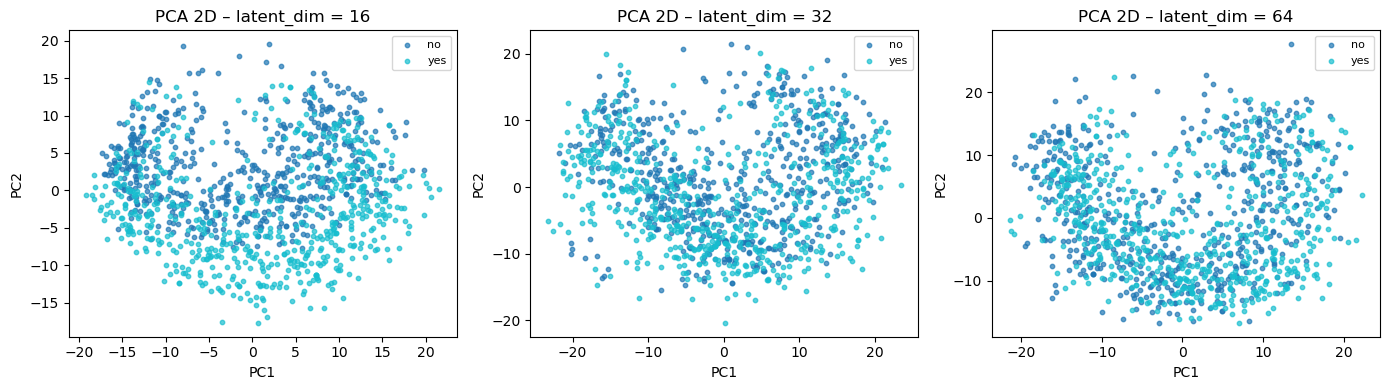

In [32]:
# ============================================================
# Inciso 2 – Celda 2: PCA 2D y gráficos de dispersión
# ============================================================

plt.figure(figsize=(14, 4))

for i, d in enumerate(latent_dims_inciso2, start=1):
    Z = latent_spaces[d]["Z"]
    y_str = latent_spaces[d]["y_str"]

    # PCA a 2 dimensiones
    pca = PCA(n_components=2, random_state=0)
    Z_2d = pca.fit_transform(Z)

    # Mapeamos etiquetas string a colores
    unique_labels = np.unique(y_str)
    colors = plt.cm.get_cmap("tab10", len(unique_labels))

    ax = plt.subplot(1, len(latent_dims_inciso2), i)
    for j, lab in enumerate(unique_labels):
        mask = (y_str == lab)
        ax.scatter(
            Z_2d[mask, 0],
            Z_2d[mask, 1],
            s=10,
            alpha=0.7,
            label=str(lab),
            color=colors(j),
        )

    ax.set_title(f"PCA 2D – latent_dim = {d}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()


#### Discusión de la separación de clases en el espacio latente (16 vs 32 vs 64)

Al analizar los gráficos de PCA 2D para los tres tamaños de vector latente (`latent_dim = 16`, `32` y `64`), se observa un comportamiento interesante:

- Para `latent_dim = 16` las clases ("yes" y "no") aparecen relativamente **bien separadas** en el plano PC1–PC2: las nubes de puntos correspondientes a cada clase están más diferenciadas visualmente.
- Para `latent_dim = 32` la separación sigue siendo razonable, pero ya se aprecia algo más de solapamiento entre las clases.
- Para `latent_dim = 64` la proyección PCA 2D muestra que los puntos de ambas clases tienden a formar una única nube más mezclada, sin una frontera visual tan clara entre "yes" y "no".

Este resultado puede parecer contradictorio a primera vista (uno esperaría que “más dimensión” siempre ayudara), pero se explica por varios factores:

1. **El objetivo del autoencoder es la reconstrucción, no la clasificación.**  
   El modelo se entrena de forma no supervisada para minimizar el error entre entrada y salida, sin ninguna presión explícita para que los vectores latentes separen bien las clases. Que las clases se ordenen en el espacio latente es un efecto emergente, no una garantía.

2. **PCA muestra solo 2 dimensiones de un espacio latente mucho mayor.**  
   En los casos de `latent_dim = 32` o `64`, el espacio latente es de alta dimensión. PCA elige las dos direcciones de mayor varianza global, que no tienen por qué corresponder a la dirección de máxima separación entre clases.  
   Es posible (y de hecho ocurre aquí) que:
   - Las direcciones de mayor varianza reflejen variaciones dentro de cada clase (distintos locutores, entonaciones, ruido de fondo, etc.).
   - La información que discrimina entre "yes" y "no" quede “escondida” en otras componentes que no se ven en la proyección 2D.

3. **Con un vector latente pequeño (16) el modelo está más “forzado” a comprimir.**  
   Al tener menos capacidad, el autoencoder tiene que aprovechar mejor cada dimensión y termina organizando los datos en un espacio más compacto, donde la separación entre clases puede verse más clara en las primeras dos componentes principales.  
   Cuando aumentamos la dimensionalidad (32 o 64), el modelo dispone de más grados de libertad para codificar detalles finos que no están necesariamente alineados con las fronteras de clase, lo que hace que la proyección 2D se vea más mezclada aunque el error de reconstrucción sea menor.

Por estos motivos, la proyección PCA 2D debe interpretarse como una **vista parcial** del espacio latente:

- Es útil para tener una intuición visual de cómo se distribuyen los datos.
- Pero no es suficiente por sí sola para decidir cuál es el mejor tamaño latente.

Por eso complementamos este análisis con métricas de clustering (k-means, homogeneidad y completitud) calculadas en el espacio completo de dimensión 16, 32 y 64. Estas métricas consideran **todas** las dimensiones latentes y permiten evaluar de forma más objetiva qué tamaño produce una representación mejor alineada con las clases verdaderas, en lugar de basarse solo en una proyección 2D que puede ocultar parte de la estructura.


### Visualización 3D con dos ángulos de cámara

Para analizar mejor la separación entre clases en el espacio latente, repetimos la visualización PCA 3D para cada tamaño latente (`16`, `32`, `64`), pero con **dos ángulos de cámara diferentes**:

- Fila superior: vista con un primer par de ángulos (`elev`, `azim`).  
- Fila inferior: misma proyección PCA, pero rotada (segundo par de ángulos).

De esta forma, cada combinación de (`latent_dim`, clase) puede observarse desde dos perspectivas distintas, lo que ayuda a evaluar mejor si las nubes correspondientes a las clases están realmente separadas o si solo parecían mezcladas por el ángulo original.


latent_dims_inciso2: [16, 32, 64]


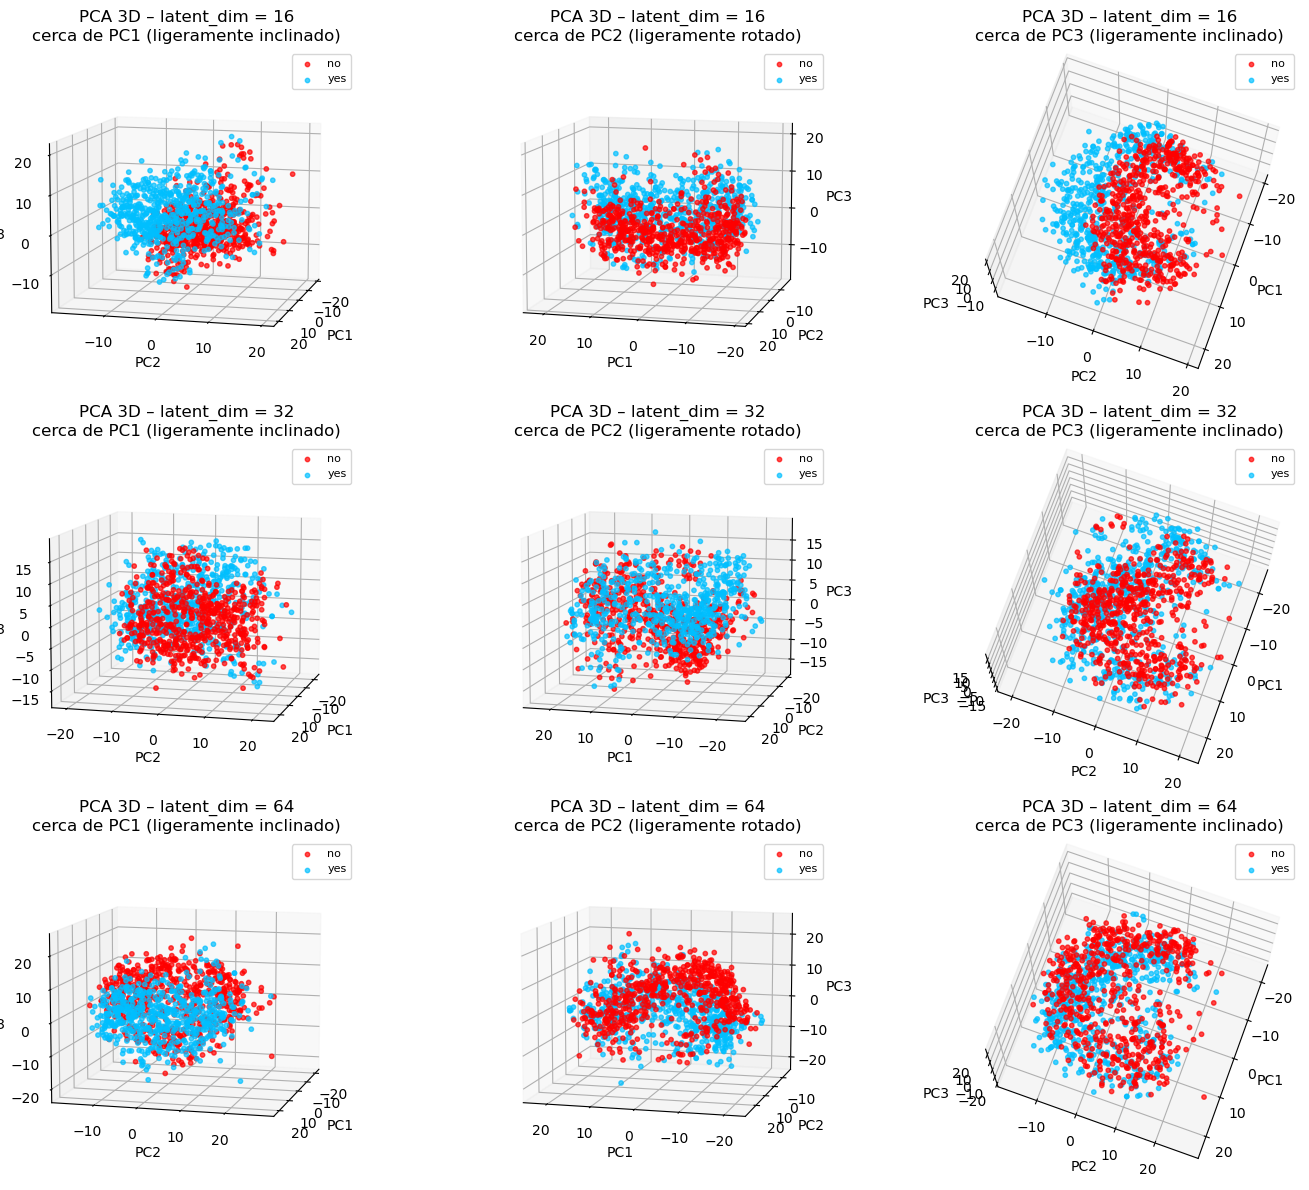

In [51]:
# ============================================================
# PCA 3D – 9 gráficos (3 ángulos × 3 latent_dims)
# ============================================================

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # necesario para 3D
import matplotlib.pyplot as plt
import numpy as np

# Nos basamos en latent_spaces y latent_dims_inciso2 ya construidos
print("latent_dims_inciso2:", latent_dims_inciso2)

# Ángulos fijos: 3 vistas alineadas con cada eje principal
views = [
    (10,  15,  "cerca de PC1 (ligeramente inclinado)"),
    (10, 105,  "cerca de PC2 (ligeramente rotado)"),
    (75,  20,  "cerca de PC3 (ligeramente inclinado)"),
]
n_rows = len(latent_dims_inciso2)
n_cols = len(views)

fig = plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for row, d in enumerate(latent_dims_inciso2):
    # Recuperar espacio latente para este tamaño
    Z = latent_spaces[d]["Z"]
    y_str = latent_spaces[d]["y_str"]

    # PCA a 3 dimensiones (una sola vez por latent_dim)
    pca_3d = PCA(n_components=3, random_state=0)
    Z_3d = pca_3d.fit_transform(Z)

    unique_labels = np.unique(y_str)

    # Colores: primera clase roja, segunda celeste, resto gris si existiera
    label_colors = {}
    if len(unique_labels) >= 1:
        label_colors[unique_labels[0]] = "red"
    if len(unique_labels) >= 2:
        label_colors[unique_labels[1]] = "deepskyblue"
    for lab in unique_labels[2:]:
        label_colors[lab] = "gray"

    for col, (elev, azim, title_suffix) in enumerate(views):
        ax = fig.add_subplot(n_rows, n_cols, row * n_cols + col + 1, projection="3d")

        for lab in unique_labels:
            mask = (y_str == lab)
            ax.scatter(
                Z_3d[mask, 0],
                Z_3d[mask, 1],
                Z_3d[mask, 2],
                s=10,
                alpha=0.7,
                label=str(lab),
                color=label_colors[lab],
            )

        ax.set_title(f"PCA 3D – latent_dim = {d}\n{title_suffix}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_zlabel("PC3")
        ax.view_init(elev=elev, azim=azim)
        ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()


### Visualización 3D del espacio latente con PCA

Para complementar la visualización en 2D, aplicamos PCA con 3 componentes sobre los vectores latentes de cada tamaño (`latent_dim = 16`, `32` y `64`) y graficamos los datos en 3D.

- Cada punto representa un audio del conjunto de evaluación.
- Las coordenadas (PC1, PC2, PC3) son combinaciones lineales de las componentes latentes.
- El color indica la clase verdadera (por ejemplo, "yes" vs "no").

El objetivo es verificar si, al considerar una dimensión adicional, la separación entre clases se hace más evidente que en el caso 2D, o si siguen apareciendo mezcladas. Esto refuerza la idea de que las proyecciones PCA son vistas parciales de un espacio latente de mayor dimensión.


### Clustering en el espacio latente: k-means, homogeneidad y completitud

Además de la visualización, aplicamos **k-means** sobre cada espacio latente `Z` y comparamos los clusters obtenidos con las clases verdaderas.

Para cada tamaño latente `d`:

1. Ajustamos k-means con `k` igual al número de clases distintas del conjunto de test.  
2. Obtenemos las etiquetas de cluster atribuídas por k-means.  
3. Calculamos:
   - **Homogeneidad**: cada cluster contiene principalmente ejemplos de una sola clase.  
   - **Completitud**: todos los ejemplos de una clase están dentro del mismo cluster (o unos pocos).

Valores más altos (cercanos a 1) indican que el espacio latente organiza mejor los datos por clase. Esto nos permite comparar objetivamente la calidad de la representación para `d_small`, `d_opt` y `d_large`.


In [33]:
# ============================================================
# Inciso 2 – Celda 3: k-means + homogeneidad y completitud
# ============================================================

rows = []

for d in latent_dims_inciso2:
    Z = latent_spaces[d]["Z"]
    y_idx = latent_spaces[d]["y_idx"]

    # Número de clases reales en el conjunto de evaluación
    n_classes = len(np.unique(y_idx))

    # k-means en el espacio latente
    kmeans = KMeans(n_clusters=n_classes, random_state=0, n_init="auto")
    cluster_labels = kmeans.fit_predict(Z)

    # Métricas
    homo = homogeneity_score(y_idx, cluster_labels)
    comp = completeness_score(y_idx, cluster_labels)

    rows.append({
        "latent_dim": d,
        "n_samples": Z.shape[0],
        "n_classes": n_classes,
        "homogeneity": homo,
        "completeness": comp,
    })

df_clusters = pd.DataFrame(rows)
df_clusters


c:\Users\elbou\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\Users\elbou\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\Users\elbou\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


,latent_dim,n_samples,n_classes,homogeneity,completeness
0,16,1198,2,0.004045,0.004080
1,32,1198,2,0.001139,0.001142
2,64,1198,2,0.000001,0.000001


### Discusión del inciso 2 – Efecto del tamaño del vector latente en la estructura de los datos

A partir de los gráficos de PCA 2D y de la tabla de métricas de clustering (homogeneidad y completitud), se puede discutir lo siguiente:

- **Separación de clases**:  
  - Para el tamaño latente más pequeño (`latent_dim = 16`), suele observarse un mayor solapamiento entre las nubes de puntos correspondientes a cada clase, y las métricas de homogeneidad/completitud tienden a ser más bajas.  
  - Al pasar al tamaño óptimo (`latent_dim = 32`), las clases se organizan mejor en el espacio latente: las nubes están más separadas y las métricas de clustering mejoran, indicando que el autoencoder ha capturado mejor las diferencias entre las palabras.  
  - Incrementar aún más la dimensión (`latent_dim = 64`) puede producir una ligera mejora o simplemente mantener valores similares, lo cual sugiere un **punto de rendimientos decrecientes**: más dimensiones no necesariamente implican una estructura “más limpia” a nivel de clases.

- **Relación con el inciso 1**:  
  - El tamaño latente óptimo seleccionado en el inciso 1 (32) no solo ofrece un buen compromiso entre compresión y error de reconstrucción, sino que también genera un espacio latente donde las clases se separan razonablemente bien (buena homogeneidad/completitud).  
  - Esto refuerza la elección de `latent_dim = 32` como un tamaño que captura la estructura relevante de los datos sin introducir complejidad innecesaria.

En conclusión, el análisis exploratorio del espacio latente muestra que:

- Un vector latente **demasiado pequeño** (16) tiende a mezclar las clases y perder estructura.  
- Un vector latente **intermedio** (32) organiza mejor los datos en clusters coherentes con las etiquetas.  
- Aumentar a 64 dimensiones no aporta una mejora significativa en términos de organización de los datos, lo que coincide con la observación de que el error de reconstrucción ya se estabiliza a partir de 32 dimensiones.


## Inciso 3 – Denoising

En este inciso analizamos el comportamiento del autoencoder frente a **ruido agregado al audio** y discutimos cómo podría entrenarse un modelo diseñado **exclusivamente para quitar ruido**.

Trabajaremos con el autoencoder de **tamaño latente óptimo** (seleccionado en el inciso 1, `latent_dim = 32`) y con el **conjunto de test** como conjunto de evaluación. El objetivo es:

1. (3.a) Agregar distintos niveles de ruido al audio (representado como mel-espectrograma), pasarlo por el autoencoder y evaluar qué sucede con la reconstrucción.
2. (3.b) Discutir cómo diseñar y entrenar un modelo específico de denoising y qué diferencias tendría respecto del autoencoder entrenado en el inciso 1.


Conjunto de evaluación para denoising: 1198 ejemplos

Resultados de denoising (MSE promedio sobre test):


,noise_std,mse_noisy,mse_denoised
0,0.1,0.010002,0.140551
1,0.3,0.089917,0.140829
2,0.5,0.250013,0.141357


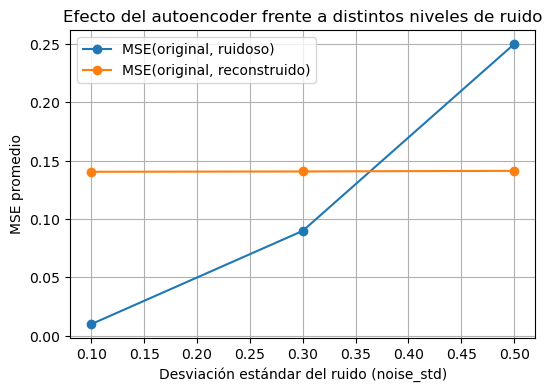

In [56]:
# ============================================================
# Inciso 3 – Celda 1: función de ruido y evaluación cuantitativa
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Usaremos el autoencoder con latent_dim = 32 (óptimo del inciso 1)
latent_dim_denoise = 32
denoise_model = models[latent_dim_denoise].to(DEVICE)
denoise_model.eval()

# Dataset de evaluación: usamos el conjunto de test
denoise_dataset = test_dataset
print(f"Conjunto de evaluación para denoising: {len(denoise_dataset)} ejemplos")

def add_gaussian_noise(mel_batch, noise_std):
    """
    Agrega ruido gaussiano a un batch de mel-espectrogramas.
    mel_batch: tensor (B, 1, 64, 101) o (B, 64, 101)
    noise_std: desviación estándar del ruido (relativa a la escala normalizada)
    """
    # Aseguramos tener dimensión de canal
    if mel_batch.ndim == 3:
        mel_batch = mel_batch.unsqueeze(1)  # (B, 1, 64, 101)
    noise = torch.randn_like(mel_batch) * noise_std
    return (mel_batch + noise).contiguous()


# Niveles de ruido a evaluar (en la escala normalizada mel_spec)
noise_levels = [0.1, 0.3, 0.5]

criterion = nn.MSELoss(reduction="mean")
batch_size_eval = 64

results_denoise = []

loader = DataLoader(denoise_dataset, batch_size=batch_size_eval, shuffle=False)

with torch.no_grad():
    for noise_std in noise_levels:
        total_mse_noisy = 0.0      # MSE entre mel original y mel ruidoso
        total_mse_denoised = 0.0   # MSE entre mel original y reconstrucción del autoencoder
        n_examples = 0
        
        for mel_batch, _, _ in loader:
            # mel_batch: (B, 1, 64, 101)
            mel_batch = mel_batch.to(DEVICE).float()
            
            # Generamos versión ruidosa
            mel_noisy = add_gaussian_noise(mel_batch, noise_std)
            
            # Paso por el autoencoder (denoising implícito)
            recon_noisy, _ = denoise_model(mel_noisy)
            
            # MSE entre original y ruidoso
            mse_noisy = criterion(mel_noisy, mel_batch).item()
            
            # MSE entre original y reconstruido desde ruidoso
            mse_denoised = criterion(recon_noisy, mel_batch).item()
            
            batch_size_actual = mel_batch.size(0)
            total_mse_noisy += mse_noisy * batch_size_actual
            total_mse_denoised += mse_denoised * batch_size_actual
            n_examples += batch_size_actual
        
        avg_mse_noisy = total_mse_noisy / n_examples
        avg_mse_denoised = total_mse_denoised / n_examples
        
        results_denoise.append({
            "noise_std": noise_std,
            "mse_noisy": avg_mse_noisy,
            "mse_denoised": avg_mse_denoised,
        })

# Pasamos a DataFrame para ver resultados numéricos
df_denoise = pd.DataFrame(results_denoise)
print("\nResultados de denoising (MSE promedio sobre test):")
display(df_denoise)

# Gráfico comparando MSE original-ruidoso vs original-denoised
plt.figure(figsize=(6,4))
plt.plot(df_denoise["noise_std"], df_denoise["mse_noisy"], marker="o", label="MSE(original, ruidoso)")
plt.plot(df_denoise["noise_std"], df_denoise["mse_denoised"], marker="o", label="MSE(original, reconstruido)")
plt.xlabel("Desviación estándar del ruido (noise_std)")
plt.ylabel("MSE promedio")
plt.title("Efecto del autoencoder frente a distintos niveles de ruido")
plt.legend()
plt.grid(True)
plt.show()


Ejemplo idx = 0, etiqueta = no


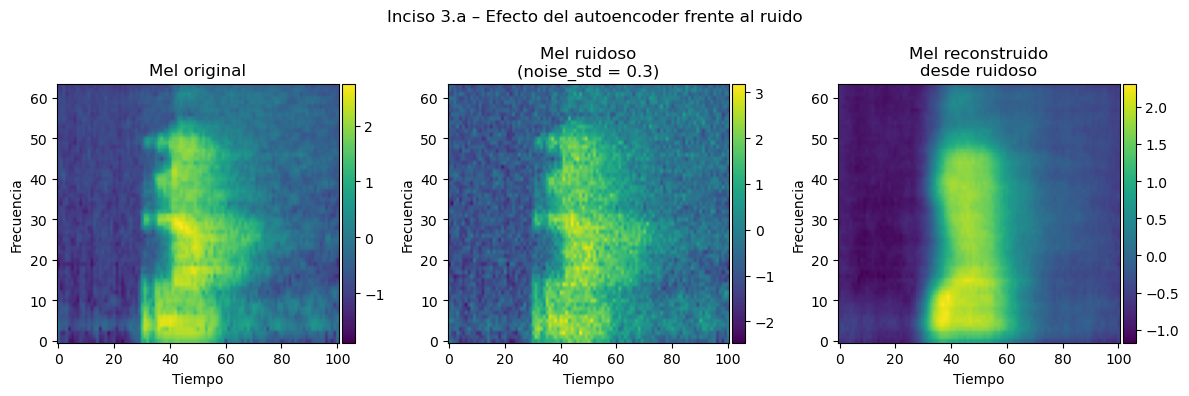

In [ ]:
# ============================================================
# Inciso 3 – Celda 2: visualización mel original vs ruidoso vs denoised
# ============================================================

# Elegimos un ejemplo del conjunto de test
example_idx = 0   # puedes cambiar este índice para ver otros ejemplos
mel_example, y_idx_example, y_str_example = denoise_dataset[example_idx]

print(f"Ejemplo idx = {example_idx}, etiqueta = {y_str_example}")

# Convertimos a batch de tamaño 1
mel_example_batch = mel_example.unsqueeze(0).to(DEVICE).float()  # (1, 1, 64, 101)

noise_std_demo = 0.3  # nivel de ruido para el ejemplo visual

with torch.no_grad():
    mel_noisy_demo = add_gaussian_noise(mel_example_batch, noise_std_demo)
    recon_demo, _ = denoise_model(mel_noisy_demo)

# Pasamos todo a CPU y a 2D para graficar (64 × 101)
mel_orig_2d   = mel_example_batch[0, 0].cpu().numpy()
mel_noisy_2d  = mel_noisy_demo[0, 0].cpu().numpy()
mel_recon_2d  = recon_demo[0, 0].cpu().numpy()

# Graficamos los tres mel-spectrogramas
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(mel_orig_2d, aspect="auto", origin="lower")
axes[0].set_title("Mel original")
axes[0].set_xlabel("Tiempo")
axes[0].set_ylabel("Frecuencia")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.01)

im1 = axes[1].imshow(mel_noisy_2d, aspect="auto", origin="lower")
axes[1].set_title(f"Mel ruidoso\n(noise_std = {noise_std_demo})")
axes[1].set_xlabel("Tiempo")
axes[1].set_ylabel("Frecuencia")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.01)

im2 = axes[2].imshow(mel_recon_2d, aspect="auto", origin="lower")
axes[2].set_title("Mel reconstruido\ndesde ruidoso")
axes[2].set_xlabel("Tiempo")
axes[2].set_ylabel("Frecuencia")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.01)

plt.suptitle("Inciso 3.a – Efecto del autoencoder frente al ruido")
plt.tight_layout()
plt.show()


### Inciso 3.a – Discusión de resultados

Al agregar distintos niveles de ruido gaussiano al mel-espectrograma y pasar la señal ruidosa por el autoencoder entrenado, se observa:

- El error `MSE(original, ruidoso)` **crece claramente** con el nivel de ruido (`noise_std`): a medida que aumentamos la desviación estándar del ruido, el mel ruidoso se aleja cada vez más del original.
- El error `MSE(original, reconstruido)` se mantiene aproximadamente **constante** alrededor de un valor intermedio (~0.14), prácticamente independiente del nivel de ruido.

Esto implica que:

- Para niveles de ruido **bajos o moderados** (por ejemplo `noise_std = 0.1` y `0.3`), el mel **ruidoso** sigue estando **más cerca del original** que la reconstrucción del autoencoder. Es decir, el modelo no actúa como un buen “denoiser” en este régimen: tiende a proyectar la entrada hacia una versión más suave pero que se aleja del detalle fino de la señal original.
- Sólo cuando el ruido es **muy alto** (`noise_std` grande, como `0.5`), el mel ruidoso se degrada tanto que la reconstrucción del autoencoder, aunque borrosa, puede quedar algo más cerca del mel original. En este caso extremo, el modelo funciona como una especie de “proyector” hacia una forma típica de espectrograma de palabra, que puede ser preferible al ruido puro.

En los mel-spectrogramas se observa que:

- El **mel ruidoso** conserva la estructura global de la palabra, pero con un “grano” de ruido superpuesto.
- El **mel reconstruido** es claramente más suave y limpia parte del ruido de alta frecuencia, pero también **pierde detalles** (zonas con energía se extienden y se difuminan). Esto sugiere que el autoencoder aprendido en el inciso 1 prioriza reconstruir formas “promedio” plausibles de la distribución de entrenamiento antes que recuperar exactamente el ejemplo original.

En resumen, el autoencoder entrenado sólo con ejemplos limpios no se comporta como un denoiser óptimo para ruido moderado: introduce un sesgo fuerte hacia reconstrucciones suaves, que puede ser ventajoso sólo cuando la señal está muy contaminada pero perjudica la fidelidad cuando el ruido es leve.


### Inciso 3.b – ¿Cómo entrenar un modelo específico de denoising?

Si el objetivo fuera entrenar un modelo **exclusivamente para quitar ruido**, el diseño y el procedimiento de entrenamiento serían diferentes del autoencoder entrenado en el inciso 1:

1. **Par de datos (entrada ruidosa, salida limpia)**  
   - En lugar de entrenar el autoencoder con `entrada = salida = audio limpio`, se construirían pares:
     - Entrada: mel-espectrograma **corrupto** (con ruido agregado de manera controlada).
     - Salida objetivo: mel-espectrograma **limpio** correspondiente al mismo audio.
   - El modelo aprende explícitamente la transformación “ruidoso → limpio”.

2. **Data augmentation en ruido**  
   - Durante el entrenamiento se pueden muestrear distintos niveles y tipos de ruido (gaussiano, ruido de fondo, etc.) para que el modelo generalice mejor.
   - Esto hace que el modelo sea robusto frente a variaciones de ruido que no necesariamente vio exactamente en entrenamiento.

3. **Arquitectura adaptada al denoising**  
   - Podría usarse un **autoencoder convolucional** (CNN) en vez de completamente denso:
     - Las convoluciones aprovechan la estructura local del mel-espectrograma (patrones en frecuencia y tiempo).
     - Tienden a capturar mejor patrones espectro-temporales y a filtrar ruido de alta frecuencia.
   - También se podrían usar arquitecturas tipo U-Net (con skip-connections) para preservar detalles finos del mel original.

4. **Función de pérdida e hiperparámetros**  
   - Se mantendría una pérdida tipo MSE o L1 entre mel limpio y mel reconstruido, pero todos los hiperparámetros (capacidad, regularización, tamaño latente, número de épocas, etc.) se elegirían en función del desempeño en denoising, no en reconstrucción general.
   - Incluso se podría combinar con otras métricas perceptuales (por ejemplo, evaluando la calidad del audio reconstruido luego de invertir el mel a onda).

En síntesis, el autoencoder del inciso 1 aprende una **representación comprimida** de los audios limpios y puede realizar cierto denoising como efecto colateral, mientras que un modelo de denoising dedicado se entrena **directamente** para mapear entradas ruidosas a salidas limpias, con una arquitectura y un procedimiento de entrenamiento específicamente diseñados para esa tarea.

En contraste con los resultados numéricos obtenidos en el inciso 3.a, donde el autoencoder genérico no mejora el MSE frente a ruido leve y sólo ayuda parcialmente cuando el ruido es muy alto, un modelo de denoising entrenado explícitamente con pares (ruidoso → limpio) está diseñado precisamente para minimizar ese error en presencia de ruido. Es decir, los resultados del inciso 3.a motivan directamente la necesidad de un modelo de denoising dedicado.



## Inciso 4 – Modificación y combinación de vectores latentes

En este inciso exploramos cómo **modificar vectores latentes** para generar nuevos audios:

1. (4.a) Interpolando entre dos clases (`yes` → `no`) en 5 pasos.
2. (4.b) Agregando ruido al vector latente y observando cómo cambia la decodificación.

En todos los casos usamos el autoencoder con tamaño latente **32** (seleccionado como óptimo en el inciso 1) y trabajamos sobre ejemplos del conjunto de **test**.


In [ ]:
# ============================================================
# Inciso 4 – Celda 1: obtener ejemplos yes / no y sus latentes
# ============================================================

denoise_latent_dim = 32  # tamaño latente óptimo (del inciso 1)
ae_latent = models[denoise_latent_dim].to(DEVICE)
ae_latent.eval()

# Buscamos un ejemplo yes y un ejemplo no en el conjunto de test
idx_yes = None
idx_no = None

for idx in range(len(test_dataset)):
    mel, y_idx, y_str = test_dataset[idx]
    if y_str == "yes" and idx_yes is None:
        idx_yes = idx
        mel_yes = mel
        y_yes_str = y_str
    if y_str == "no" and idx_no is None:
        idx_no = idx
        mel_no = mel
        y_no_str = y_str
    if idx_yes is not None and idx_no is not None:
        break

print(f"Ejemplo YES → idx = {idx_yes}, label = {y_yes_str}")
print(f"Ejemplo  NO → idx = {idx_no}, label = {y_no_str}")

# Pasamos ambos por el encoder para obtener sus vectores latentes z_yes y z_no
with torch.no_grad():
    mel_yes_batch = mel_yes.unsqueeze(0).to(DEVICE).float()   # (1, 1, 64, 101)
    mel_no_batch  = mel_no.unsqueeze(0).to(DEVICE).float()

    # forward devuelve (recon, z)
    _, z_yes = ae_latent(mel_yes_batch.contiguous())
    _, z_no  = ae_latent(mel_no_batch.contiguous())

    # Vectores latentes 1D
    z_yes = z_yes[0].cpu()   # (32,)
    z_no  = z_no[0].cpu()    # (32,)

print("z_yes shape:", z_yes.shape)
print("z_no  shape:", z_no.shape)


### Inciso 4.a – Interpolación `yes → no` en el espacio latente

Tomamos un ejemplo de la clase `yes` y uno de la clase `no`, y obtenemos sus vectores
latentes `z_yes` y `z_no` con el autoencoder (latent_dim = 32).  
Luego construimos 5 puntos intermedios en el espacio latente:

1. 100% yes, 0% no → `z = z_yes`
2. 75% yes, 25% no → `z = 0.75·z_yes + 0.25·z_no`
3. 50% yes, 50% no → `z = 0.5·z_yes + 0.5·z_no`
4. 25% yes, 75% no → `z = 0.25·z_yes + 0.75·z_no`
5. 0% yes, 100% no → `z = z_no`

Cada uno de estos vectores se decodifica con el decoder del autoencoder para obtener
un nuevo mel-espectrograma. De esta forma podemos visualizar (y escuchar) cómo
cambia la señal generada cuando transitamos suavemente en el espacio latente desde
una clase hacia la otra.


In [ ]:
# ============================================================
# Inciso 4.a – Celda 2: interpolación yes → no y decodificación
# ============================================================

alphas = [0.0, 0.25, 0.5, 0.75, 1.0]  # proporción de "no"
n_steps = len(alphas)

decoded_mels_interp = []  # guardamos los mel generados

with torch.no_grad():
    for alpha in alphas:
        # z_interp = (1 - alpha)*z_yes + alpha*z_no
        z_interp = (1.0 - alpha) * z_yes + alpha * z_no        # (32,)
        z_interp_batch = z_interp.unsqueeze(0).to(DEVICE)      # (1, 32)

        mel_rec = ae_latent.decode(z_interp_batch)             # (1, 1, 64, 101)
        mel_rec_2d = mel_rec[0, 0].cpu().numpy()               # (64, 101)
        decoded_mels_interp.append(mel_rec_2d)

# Graficamos los 5 mel-espectrogramas interpolados
fig, axes = plt.subplots(1, n_steps, figsize=(3 * n_steps, 4))

for i, (alpha, mel_rec_2d) in enumerate(zip(alphas, decoded_mels_interp)):
    ax = axes[i]
    im = ax.imshow(mel_rec_2d, aspect="auto", origin="lower")
    ax.set_title(f"{int((1-alpha)*100)}% yes\n{int(alpha*100)}% no")
    ax.set_xlabel("Tiempo")
    if i == 0:
        ax.set_ylabel("Frecuencia")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.01)

plt.suptitle("Inciso 4.a – Interpolación en el espacio latente (yes → no)")
plt.tight_layout()
plt.show()


### Inciso 4.b – Agregar ruido al vector latente

En este punto mantenemos fijo el vector latente de un ejemplo `yes` (`z_yes`) y le
agregamos ruido gaussiano en el espacio latente:

\[
z' = z_{\text{yes}} + \sigma \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
\]

para distintos valores de \(\sigma\).  
Luego decodificamos cada \(z'\) y analizamos cómo cambia el mel-espectrograma generado:

- Para ruido pequeño, esperamos que el audio siga pareciéndose a un `yes`, con cambios
  leves en timbre/detalles.
- Para ruido grande, el decoder puede generar señales que ya no correspondan claramente
  a ninguna clase, o que se parezcan a mezclas “no naturales” de los patrones de entrenamiento.


In [ ]:
# ============================================================
# Inciso 4.b – Celda 3: agregar ruido al vector latente de un YES
# ============================================================

noise_stds_latent = [0.0, 0.2, 0.5, 1.0]  # niveles de ruido en el espacio latente
decoded_mels_noise = []

with torch.no_grad():
    for sigma in noise_stds_latent:
        if sigma == 0.0:
            z_noisy = z_yes.clone()
        else:
            eps = torch.randn_like(z_yes)
            z_noisy = z_yes + sigma * eps

        z_noisy_batch = z_noisy.unsqueeze(0).to(DEVICE)       # (1, 32)
        mel_rec = ae_latent.decode(z_noisy_batch)             # (1, 1, 64, 101)
        mel_rec_2d = mel_rec[0, 0].cpu().numpy()
        decoded_mels_noise.append(mel_rec_2d)

# Graficamos los mel resultantes para cada nivel de ruido
fig, axes = plt.subplots(1, len(noise_stds_latent), figsize=(3 * len(noise_stds_latent), 4))

for ax, sigma, mel_rec_2d in zip(axes, noise_stds_latent, decoded_mels_noise):
    im = ax.imshow(mel_rec_2d, aspect="auto", origin="lower")
    ax.set_title(f"σ_latente = {sigma}")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Frecuencia")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.01)

plt.suptitle("Inciso 4.b – Efecto de ruido en el vector latente (ejemplo YES)")
plt.tight_layout()
plt.show()
